In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el JSON
with open('../data/raw/Datos_SIATA_Aire_pm25.json') as f:
    data = json.load(f)

# Convertir a DataFrame
registros = []
for estacion in data:
    for dato in estacion['datos']:
        registros.append({
            'estacion': estacion['codigoSerial'],
            'nombre': estacion['nombre'],
            'latitud': estacion['latitud'],
            'longitud': estacion['longitud'],
            'fecha': dato['fecha'],
            'pm25': dato['valor'],
            'calidad': dato['calidad']
        })

df = pd.DataFrame(registros)
df['fecha'] = pd.to_datetime(df['fecha'])

print('Shape:', df.shape)
print('\nPrimeras filas:')
df.head()

Shape: (183981, 7)

Primeras filas:


,estacion,nombre,latitud,longitud,fecha,pm25,calidad
0,3,Girardota - S.O.S Aburrá Norte,6.379038,-75.450913,2018-08-28 04:00:00,15.0,1.0
1,3,Girardota - S.O.S Aburrá Norte,6.379038,-75.450913,2018-08-28 05:00:00,20.0,1.0
2,3,Girardota - S.O.S Aburrá Norte,6.379038,-75.450913,2018-08-28 06:00:00,29.0,1.0
3,3,Girardota - S.O.S Aburrá Norte,6.379038,-75.450913,2018-08-28 07:00:00,22.0,1.0
4,3,Girardota - S.O.S Aburrá Norte,6.379038,-75.450913,2018-08-28 08:00:00,29.0,1.0


In [5]:
# Información general del dataset
print("=== ESTACIONES ===")
print(df.groupby(['estacion', 'nombre']).size().reset_index(name='registros'))

print("\n=== RANGO DE FECHAS ===")
print("Desde:", df['fecha'].min())
print("Hasta:", df['fecha'].max())

print("\n=== ESTADÍSTICAS DE PM2.5 ===")
print(df['pm25'].describe())

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== ESTACIONES ===
    estacion                                             nombre  registros
0          3                     Girardota - S.O.S Aburrá Norte       8761
1         12                            Estación Tráfico Centro       8761
2         25  Medellín,  centro occidente - Universidad Naci...       8761
3         28                   Itagüí - Casa de Justicia Itagüí       8761
4         31      Caldas - Corporacion Universitaria Lasallista       8761
5         38          Itagüí - I.E. Concejo Municipal de Itagüí       8761
6         44           Medellín, El Poblado - Tanques La Ye EPM       8761
7         48                               Estación Tráfico Sur       8761
8         69                   Caldas - E U Joaquín Aristizabal       8761
9         78                             La Estrella - Hospital       8761
10        79     Medellín, Altavista - I.E. Pedro Octavio Amado       8761
11        80  Medellín, Villahermosa - Planta de producción ...       8761
12    

In [6]:
# Ver cuántos valores inválidos hay
print("=== VALORES INVÁLIDOS ===")
print("Valores -9999:", (df['pm25'] == -9999).sum())
print("Valores negativos:", (df['pm25'] < 0).sum())
print("Valores > 500 (imposibles):", (df['pm25'] > 500).sum())

total = len(df)
invalidos = (df['pm25'] < 0).sum() + (df['pm25'] > 500).sum()
print(f"\nTotal inválidos: {invalidos} de {total} ({invalidos/total*100:.1f}%)")
print(f"Total válidos: {total - invalidos} ({(total-invalidos)/total*100:.1f}%)")

=== VALORES INVÁLIDOS ===
Valores -9999: 1079
Valores negativos: 2329
Valores > 500 (imposibles): 1025

Total inválidos: 3354 de 183981 (1.8%)
Total válidos: 180627 (98.2%)


C:\Users\valen\AppData\Local\Temp\ipykernel_16824\1505463241.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valido['hora'] = df_valido['fecha'].dt.hour
C:\Users\valen\AppData\Local\Temp\ipykernel_16824\1505463241.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valido['mes'] = df_valido['fecha'].dt.month


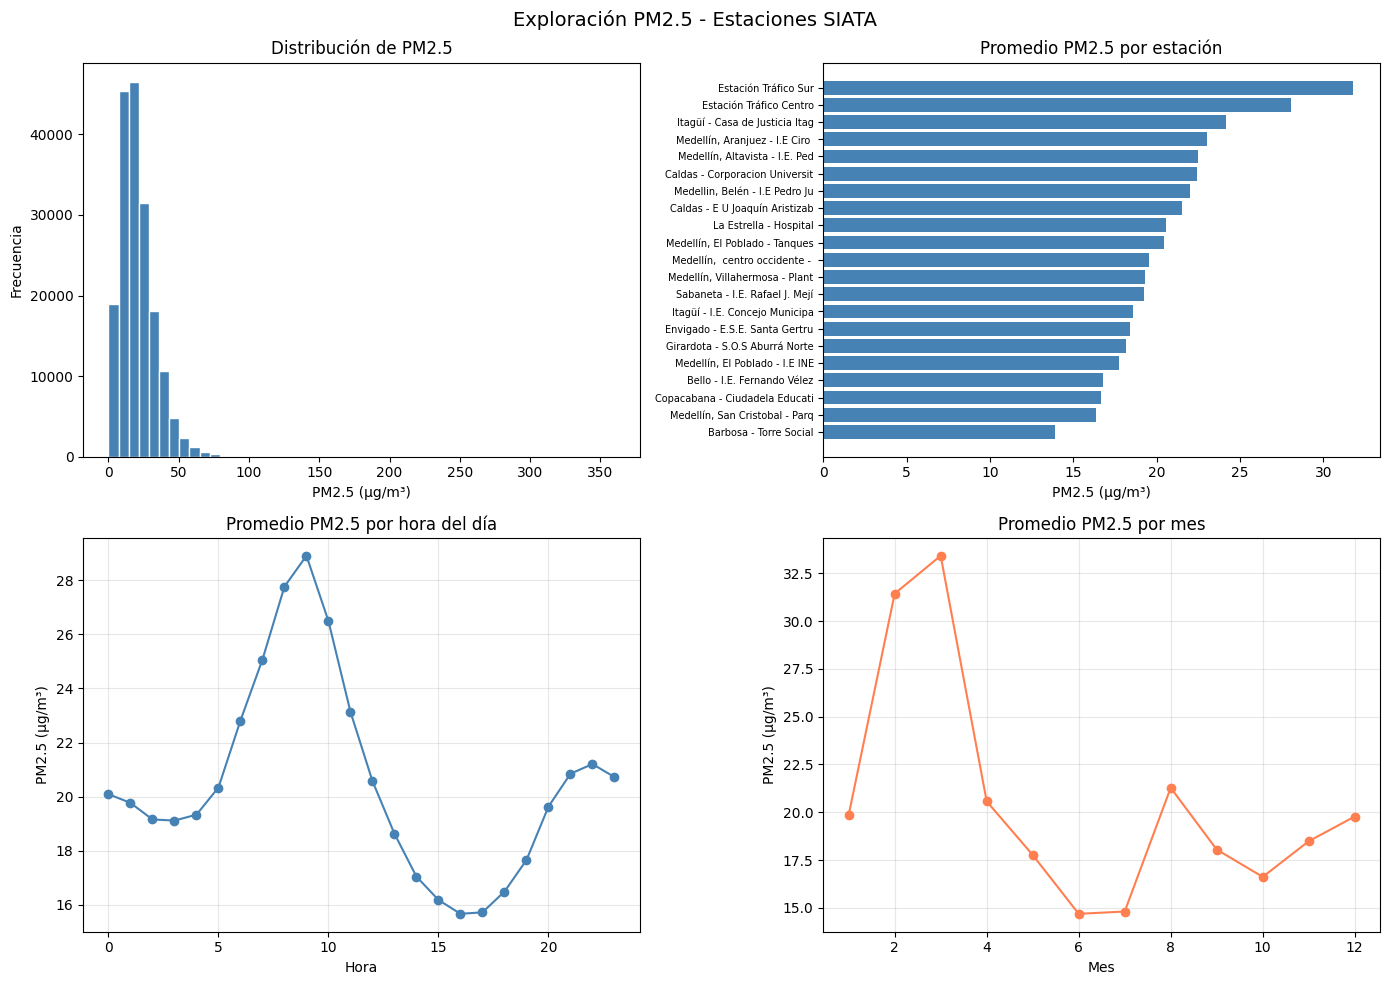

Gráfica guardada en docs/


In [7]:
# Gráficas exploratorias
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploración PM2.5 - Estaciones SIATA', fontsize=14)

# 1. Distribución de PM2.5 (solo valores válidos)
df_valido = df[(df['pm25'] >= 0) & (df['pm25'] <= 500)]
axes[0,0].hist(df_valido['pm25'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de PM2.5')
axes[0,0].set_xlabel('PM2.5 (µg/m³)')
axes[0,0].set_ylabel('Frecuencia')

# 2. Promedio por estación
promedio_estacion = df_valido.groupby('nombre')['pm25'].mean().sort_values()
axes[0,1].barh(range(len(promedio_estacion)), promedio_estacion.values, color='steelblue')
axes[0,1].set_yticks(range(len(promedio_estacion)))
axes[0,1].set_yticklabels([n[:30] for n in promedio_estacion.index], fontsize=7)
axes[0,1].set_title('Promedio PM2.5 por estación')
axes[0,1].set_xlabel('PM2.5 (µg/m³)')

# 3. Promedio por hora del día
df_valido['hora'] = df_valido['fecha'].dt.hour
promedio_hora = df_valido.groupby('hora')['pm25'].mean()
axes[1,0].plot(promedio_hora.index, promedio_hora.values, marker='o', color='steelblue')
axes[1,0].set_title('Promedio PM2.5 por hora del día')
axes[1,0].set_xlabel('Hora')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')
axes[1,0].grid(True, alpha=0.3)

# 4. Promedio por mes
df_valido['mes'] = df_valido['fecha'].dt.month
promedio_mes = df_valido.groupby('mes')['pm25'].mean()
axes[1,1].plot(promedio_mes.index, promedio_mes.values, marker='o', color='coral')
axes[1,1].set_title('Promedio PM2.5 por mes')
axes[1,1].set_xlabel('Mes')
axes[1,1].set_ylabel('PM2.5 (µg/m³)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/eda_exploracion.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfica guardada en docs/")

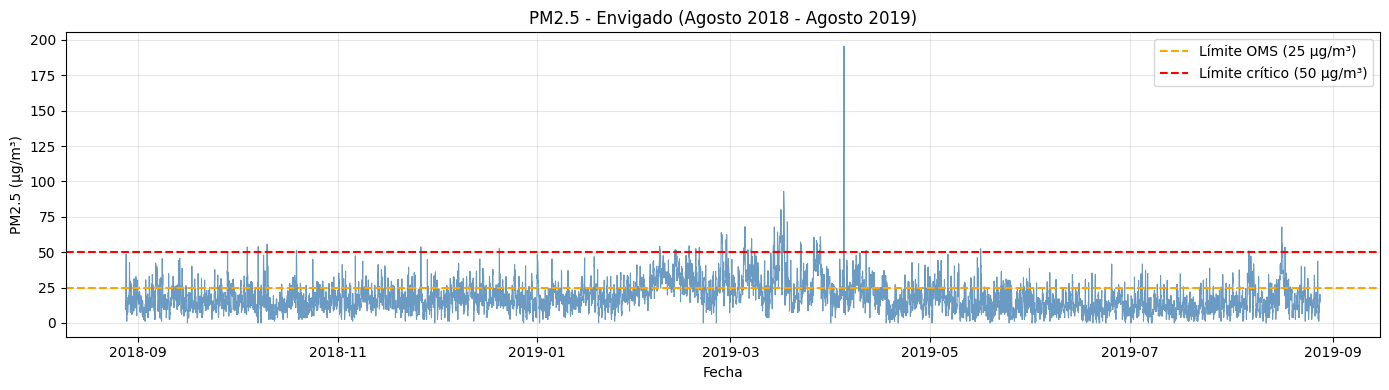

In [8]:
# Serie de tiempo de una estación (Envigado, que te queda cerca!)
estacion_envigado = df_valido[df_valido['nombre'].str.contains('Envigado')].copy()
estacion_envigado = estacion_envigado.sort_values('fecha')

plt.figure(figsize=(14, 4))
plt.plot(estacion_envigado['fecha'], estacion_envigado['pm25'], 
         color='steelblue', linewidth=0.8, alpha=0.8)
plt.title('PM2.5 - Envigado (Agosto 2018 - Agosto 2019)')
plt.xlabel('Fecha')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=25, color='orange', linestyle='--', label='Límite OMS (25 µg/m³)')
plt.axhline(y=50, color='red', linestyle='--', label='Límite crítico (50 µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/eda_serie_tiempo.png', dpi=100, bbox_inches='tight')
plt.show()